In [ ]:
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import r2_score
import seaborn as sns
import scipy.stats as st
import scanpy as sc
import anndata as ad
import pandas as pd
import histogwas.emb_gwas as eg
import numpy as np
from tqdm import tqdm
import pylab as pl
from scipy import stats
import os
from os.path import join
import glob

/home/aih/shubham.chaudhary/miniconda3/envs/milgan/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/home/aih/shubham.chaudhary/miniconda3/envs/milgan/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


In [37]:
import matplotlib.pyplot as plt
import numpy as np

def make_plots(model_pvalue, method_colors, tissue):
    fig, ax = plt.subplots(figsize=(4, 3.5))  # Adjust the figure size as needed

    pve = {}
    pvo = {}

    # Get unique keys (labels)
    keys = list(model_pvalue.keys())

    # Generate a dictionary of random colors for each label
    label_colors = {key: method_colors[key] for key in keys}

    for key in keys:
        pve[key] = -np.log10(np.linspace(0, 1, model_pvalue[key].shape[0] + 2)[1:-1])
        pvo[key] = -np.log10(np.sort(model_pvalue[key]))
        
        # Add alpha and s parameters to the scatter function
        ax.scatter(pve[key], pvo[key], label=key, color=label_colors[key], alpha=0.4, s=20)

    xlim1, xlim2 = ax.get_xlim()
    ylim1, ylim2 = ax.get_ylim()
    xlim1 = -np.log10(1)
    ylim1 = -np.log10(1)

    ax.set_xlim(xlim1, xlim2)
    ax.set_ylim(ylim1, ylim2)
    ax.set_xlabel("Expected P values", fontsize=12)
    ax.set_ylabel("Observed P values", fontsize=12)
    
    ax.plot([xlim1, xlim2], -np.log10(5e-8)*np.ones(2), color='red', linestyle=':')
    
    title = f'For tissue {tissue}'
    ax.set_title(title)

    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()  # Added to display the plot


In [3]:
# Reading the gene prediction file
model_type = ['simclr', 'kimiaNet', 'ctranspath', 'retccl', 'plip']
tissue_list = [
    'Thyroid',
]
r2 = []
p_value = {}
df_all = {}
df_all_pvalue = {}
optimizer = ['glmm']
for model_type_ in model_type:
    path = f"/lustre/groups/casale/code/users/shubham.chaudhary/output/projects/gtex/pysrc_v2/preprocessing/stage7/gene_prediction/Thyroid_{model_type_}_{'glmm'}.csv"
    df = pd.read_csv(path)
    r2.append(df['R2_score'].values)
    p_value[model_type_] = df['p_value']
    df_all[model_type_] = df.sort_values('p_value')
    df_all_pvalue[model_type_] = df_all[model_type_]['p_value']

In [36]:
method_colors = {
    'simclr': 'lightseagreen',
    'kimiaNet': 'mediumaquamarine',
    'ctranspath': 'lightpink',
    'retccl': 'palevioletred',
    'plip': '#D8BFD8',
}

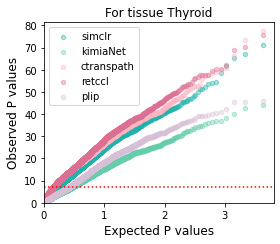

In [38]:
make_plots(df_all_pvalue, method_colors,  'Thyroid')